In [1]:
import sys
import numpy
import scipy
import brian2
import neurodynex3

print(sys.executable)
print(sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("brian2:", brian2.__version__)
print("neurodynex3 import OK")

C:\ProgramData\miniconda3\envs\bmnn\python.exe
3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:27:10) [MSC v.1944 64 bit (AMD64)]
numpy: 1.26.4
scipy: 1.12.0
brian2: 2.5.4
neurodynex3 import OK


In [2]:
from brian2 import *
prefs.codegen.target = "numpy"

start_scope()

G = NeuronGroup(1, 'dv/dt=-v/(10*ms):1', method='exact')
G.v = 1

mon = StateMonitor(G, 'v', record=True)

run(10*ms)

print("Brian2 OK")
print(mon.v[0][-1])

Brian2 OK
0.3715766910220477


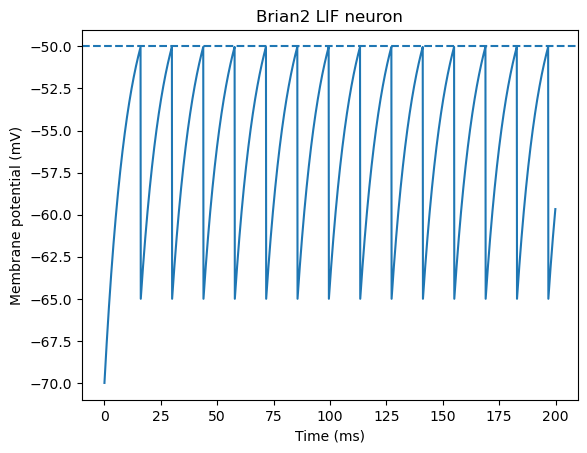

Number of spikes: 14
Spike times ms: [ 16.   29.9  43.8  57.7  71.6  85.5  99.4 113.3 127.2 141.1 155.  168.9
 182.8 196.7]


In [3]:
%matplotlib inline

from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = "numpy"
start_scope()

tau = 10*ms
v_rest = -70*mV
v_reset = -65*mV
v_th = -50*mV
R = 100*Mohm
I = 0.25*nA

eqs = '''
dv/dt = (v_rest - v + R*I)/tau : volt
'''

G = NeuronGroup(
    1,
    eqs,
    threshold='v > v_th',
    reset='v = v_reset',
    method='exact'
)

G.v = v_rest

M = StateMonitor(G, 'v', record=True)
S = SpikeMonitor(G)

run(200*ms)

plt.figure()
plt.plot(M.t/ms, M.v[0]/mV)
plt.axhline(v_th/mV, linestyle='--')
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Brian2 LIF neuron")
plt.show()

print("Number of spikes:", S.count[0])
print("Spike times ms:", S.t/ms)